In [1]:
from quantum_cva.mc_benchmark.benchmark_utils import simulate_S, price_grid_from_samples, discrete_probs_from_samples
import numpy as np
import matplotlib.pyplot as plt

# Parametric Analysis: Impact of Discretization Parameters on Price Grid Resolution

## 1. Effect of Parameter `n` (Number of Qubits)

The parameter `n` controls the **resolution and precision** of the price discretization scheme:

- **Formula**: $N_{\text{bins}} = 2^n$
- **Price Range**: Fixed interval $[\mu - 4\sigma, \mu + 4\sigma]$
- **Key Property**: The price range remains constant; only the discretization granularity changes

| Parameter $n$ | Number of Bins | Resolution | Use Case |
|---|---|---|---|
| 2 | 4 | Very coarse | Proof-of-concept |
| 4 | 16 | Coarse | Preliminary analysis |
| 6 | 64 | Medium | Standard applications |
| 8 | 256 | Fine | High-precision requirements |
| 10 | 1,024 | Very fine | Research/Benchmarking |

**Key Insight**: Increasing $n$ provides uniform refinement across the **entire probability distribution**, not just in the tails. This is critical for quantum circuit depth considerations and computational resources.

In [2]:
# Initialization: Monte Carlo simulation parameters and terminal samples
# (placed here so subsequent cells can reuse `S_by_time` and `final_prices`)
S0, mu, sigma = 5.0, 0.02, 0.25
M, T = 4, 0.5

# Number of Monte Carlo paths
N_paths = 10_000

# Time grid
t = np.linspace(0.0, T, M + 1)

# Reproducible random draws
rng = np.random.default_rng(42)
Z = rng.standard_normal(size=(N_paths, M))

# Generate marginal GBM samples (list of arrays, one per exposure date)
S_by_time = simulate_S(S0, mu, sigma, t, Z)
final_prices = S_by_time[-1]

print(f"Initialized: N_paths={N_paths}, M={M}, terminal samples shape={final_prices.shape}")

Initialized: N_paths=10000, M=4, terminal samples shape=(10000,)


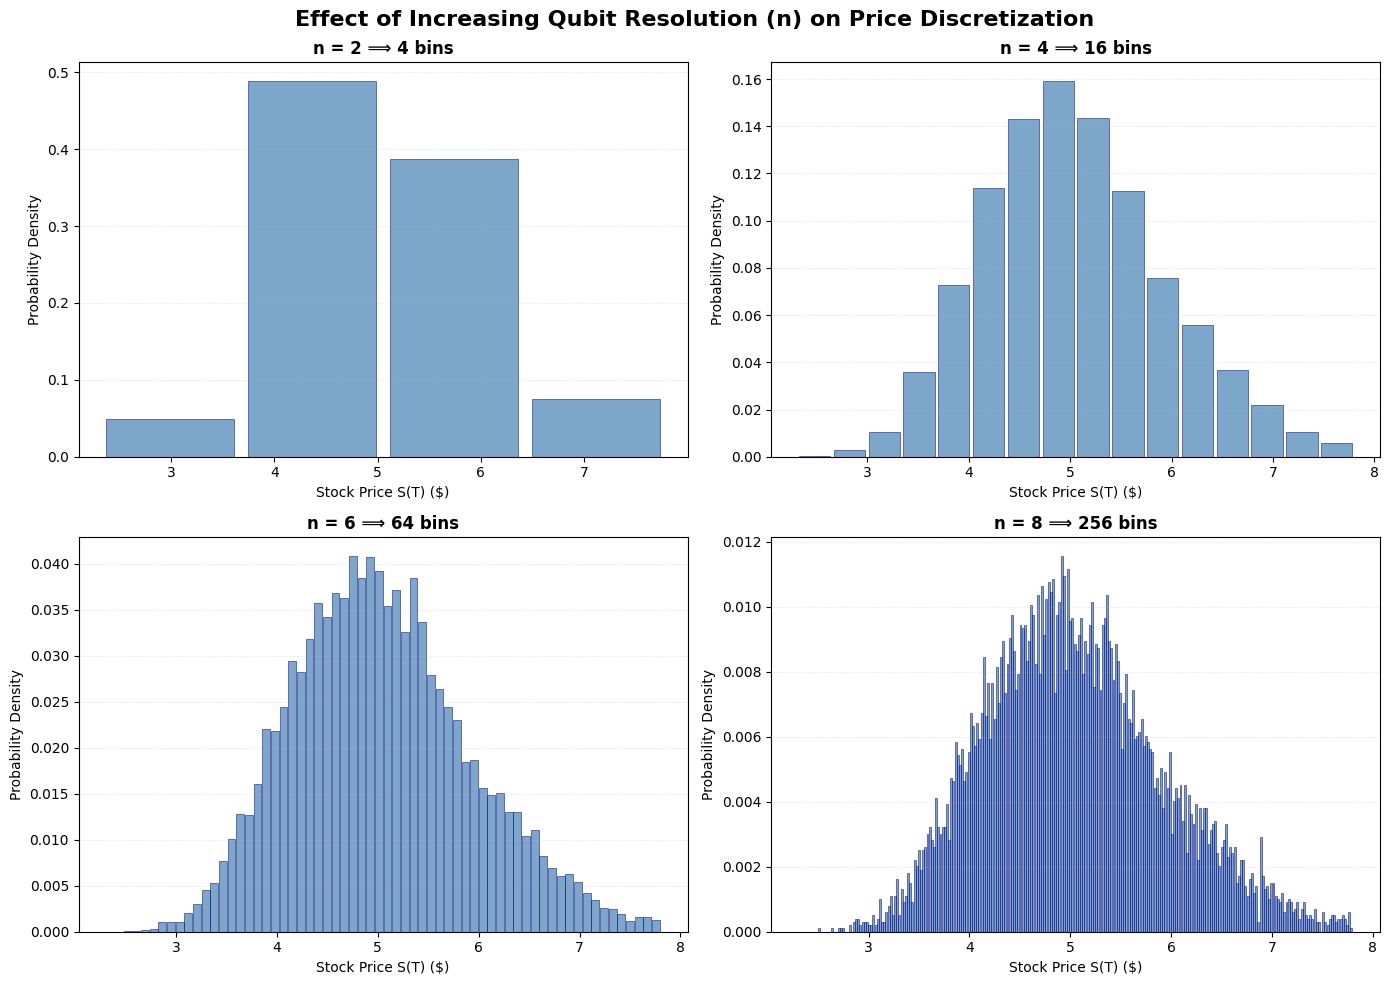

OBSERVATION: Uniform Refinement Across Price Range
Increasing n provides finer discretization in the SAME price interval.
This affects ALL price levels, not selectively the tail distribution.


In [3]:
# Comparative Analysis: Impact of Varying Qubit Resolution (n)
# This visualization demonstrates how increasing n refines the discretization
# across the fixed price range [μ - 4σ, μ + 4σ]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Effect of Increasing Qubit Resolution (n) on Price Discretization', 
             fontsize=16, fontweight='bold')

n_values = [2, 4, 6, 8]

for idx, ax in enumerate(axes.flat):
    n = n_values[idx]
    edges_n, s_mid_n = price_grid_from_samples(S_by_time, n)
    probs_n = discrete_probs_from_samples(final_prices, edges_n)
    bin_width_n = s_mid_n[1] - s_mid_n[0] if len(s_mid_n) > 1 else 1.0
    
    ax.bar(s_mid_n, probs_n, width=bin_width_n*0.9, alpha=0.7, 
           color='steelblue', edgecolor='navy', linewidth=0.5)
    ax.set_title(f'n = {n} ⟹ {2**n} bins', fontsize=12, fontweight='bold')
    ax.set_xlabel('Stock Price S(T) ($)', fontsize=10)
    ax.set_ylabel('Probability Density', fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

print("="*70)
print("OBSERVATION: Uniform Refinement Across Price Range")
print("="*70)
print("Increasing n provides finer discretization in the SAME price interval.")
print("This affects ALL price levels, not selectively the tail distribution.")

## 2. Effect of Parameter `n_sigma` (Truncation Width)

The parameter `n_sigma` controls the **extent of the price support** relative to the terminal distribution:

- **Formula**: Truncation interval = $[\mu - n_\sigma \cdot \sigma, \mu + n_\sigma \cdot \sigma]$
- **Number of Bins**: Fixed at $N = 2^n$ (unchanged)
- **Trade-off**: Wider interval captures tail risk but reduces local resolution

| Parameter $n_\sigma$ | Interval Width | Tail Coverage | Data Outside Range |
|---|---|---|---|
| 2 | μ ± 2σ | ~95.4% | ~4.6% |
| 3 | μ ± 3σ | ~99.73% | ~0.27% |
| 4 | μ ± 4σ | ~99.994% | ~0.006% |
| 5 | μ ± 5σ | ~99.99994% | ~0.00006% |

**Key Insight**: Increasing $n_\sigma$ extends the price support to capture extreme scenarios, but bin width increases proportionally, reducing granularity within each bin. This is the inverse trade-off compared to varying $n$.

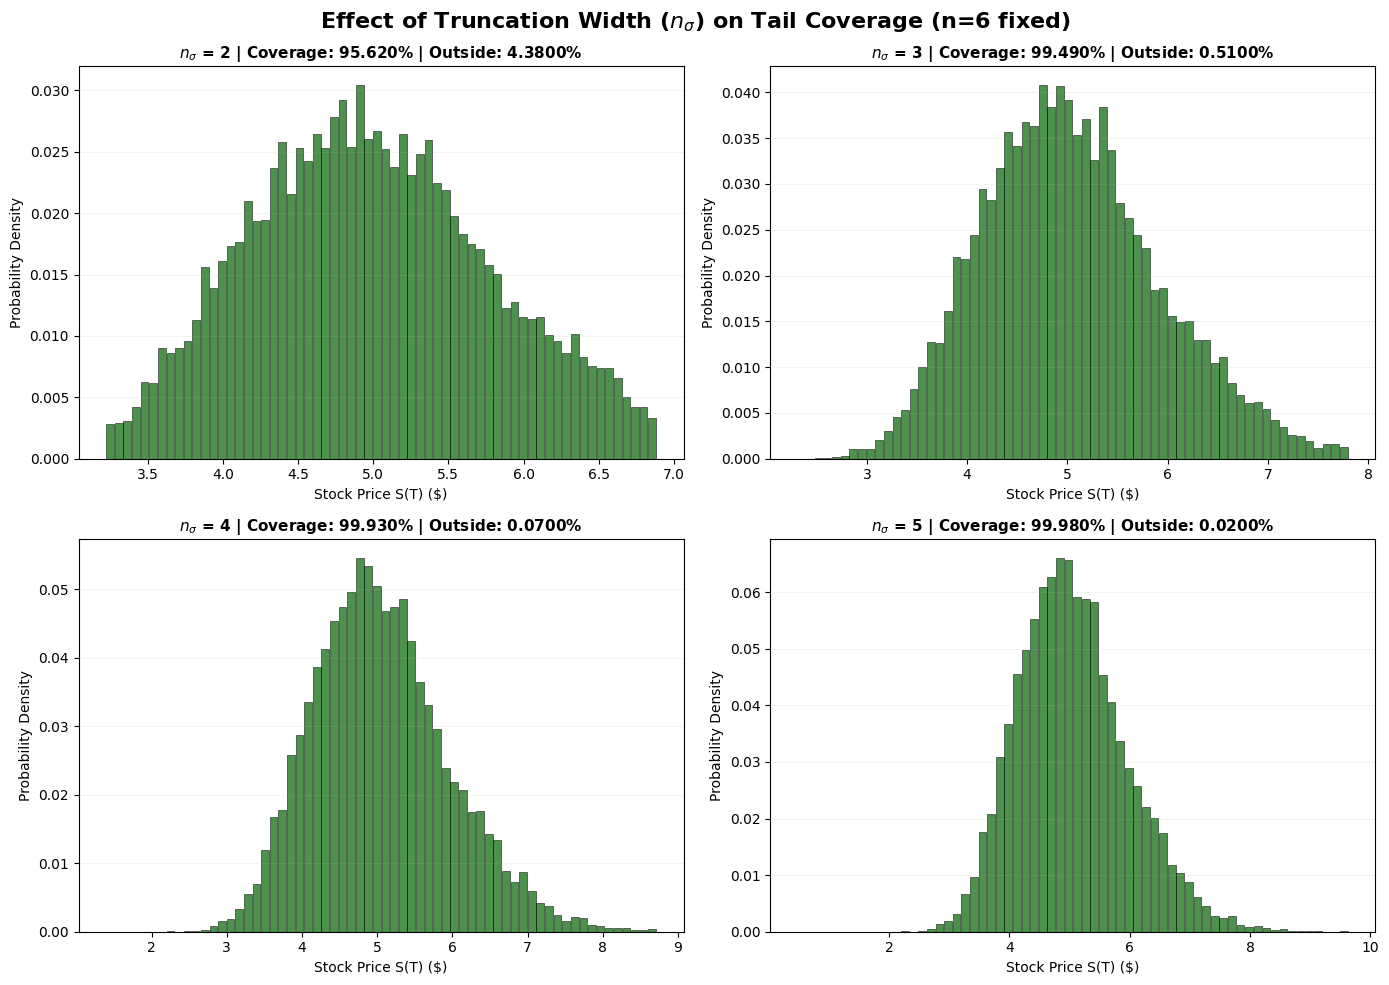

OBSERVATION: Tail Coverage vs. Local Resolution Trade-off
Increasing n_sigma extends the support to capture tail events,
but reduces the resolution (bin width increases) within the interval.


In [4]:
# Comparative Analysis: Impact of Truncation Width (n_sigma)
# Fixed discretization level (n=6) with varying coverage intervals

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Effect of Truncation Width ($n_\\sigma$) on Tail Coverage (n=6 fixed)', 
             fontsize=16, fontweight='bold')

n_sigma_values = [2, 3, 4, 5]

for idx, ax in enumerate(axes.flat):
    n_sigma = n_sigma_values[idx]
    edges_sigma, s_mid_sigma = price_grid_from_samples(S_by_time, n=6, n_sigma=n_sigma)
    
    # Compute coverage statistics
    in_range = np.sum((final_prices >= edges_sigma[0]) & (final_prices <= edges_sigma[-1]))
    pct_in_range = 100 * in_range / len(final_prices)
    pct_outside = 100 - pct_in_range
    
    probs_sigma = discrete_probs_from_samples(final_prices, edges_sigma)
    bin_width_sigma = s_mid_sigma[1] - s_mid_sigma[0] if len(s_mid_sigma) > 1 else 1.0
    
    ax.bar(s_mid_sigma, probs_sigma, width=bin_width_sigma*0.9, alpha=0.7, 
           color='darkgreen', edgecolor='black', linewidth=0.5)
    ax.set_title(f'$n_\\sigma$ = {n_sigma} | Coverage: {pct_in_range:.3f}% | Outside: {pct_outside:.4f}%', 
                fontsize=11, fontweight='bold')
    ax.set_xlabel('Stock Price S(T) ($)', fontsize=10)
    ax.set_ylabel('Probability Density', fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.show()

print("="*70)
print("OBSERVATION: Tail Coverage vs. Local Resolution Trade-off")
print("="*70)
print("Increasing n_sigma extends the support to capture tail events,")
print("but reduces the resolution (bin width increases) within the interval.")

## 3. Optimization Trade-offs: Parameter Selection Strategy

The choice of $n$ and $n_\sigma$ involves competing objectives that must be carefully balanced:

### Increasing $n$ (Qubit Resolution)
**Advantages:**
- ✓ Uniform refinement across the entire probability distribution
- ✓ Improved pricing accuracy and exposure smoothness
- ✓ Better capture of mode structure in the distribution

**Disadvantages:**
- ✗ Exponential growth in circuit depth and quantum resources
- ✗ Notebook output size constraints (large bin counts)
- ✗ Increased classical post-processing complexity

### Increasing $n_\sigma$ (Support Width)
**Advantages:**
- ✓ Captures more tail events and extreme scenarios
- ✓ Reduced probability of data loss outside the grid
- ✓ Enhanced robustness to tail risk events

**Disadvantages:**
- ✗ Coarser discretization in the main distribution support
- ✗ Reduced precision for typical (non-extreme) scenarios
- ✗ Larger bin widths may obscure important price levels

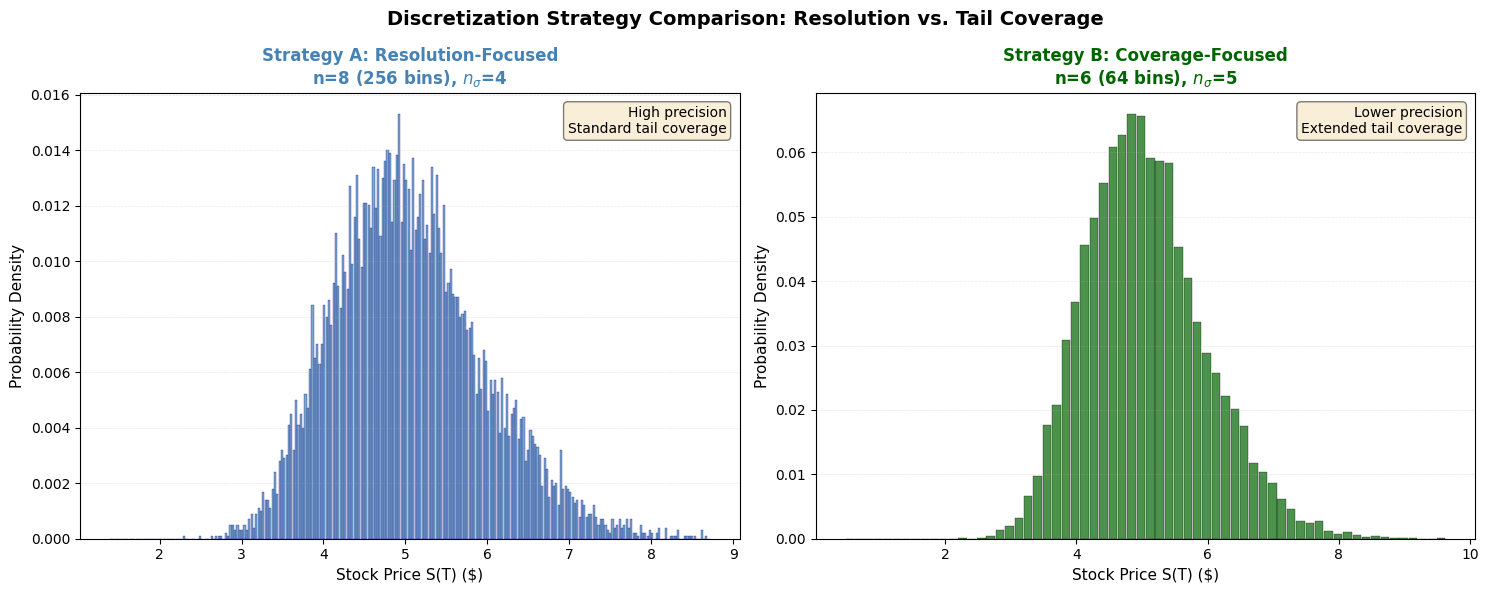

STRATEGY COMPARISON SUMMARY
Strategy A (Left):  n=8, n_sigma=4  → 256 bins in standard range
                    Advantage: Superior resolution for CVA pricing
                    Trade-off: Potential data loss in extreme tails

Strategy B (Right): n=6, n_sigma=5  → 64 bins in extended range
                    Advantage: Robust tail risk capture
                    Trade-off: Coarser pricing granularity


In [6]:
# Side-by-Side Comparison: Joint Effect of n and n_sigma Parameters
# This visualization illustrates the fundamental trade-off between
# local resolution and tail coverage in discretization schemes

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Discretization Strategy Comparison: Resolution vs. Tail Coverage', 
             fontsize=14, fontweight='bold')

# Left panel: High resolution, standard coverage
ax1 = axes[0]
edges_n8, s_mid_n8 = price_grid_from_samples(S_by_time, n=8, n_sigma=4)
probs_n8 = discrete_probs_from_samples(final_prices, edges_n8)
bin_width_n8 = s_mid_n8[1] - s_mid_n8[0] if len(s_mid_n8) > 1 else 1.0

ax1.bar(s_mid_n8, probs_n8, width=bin_width_n8*0.9, alpha=0.7, 
        color='steelblue', edgecolor='navy', linewidth=0.3)
ax1.set_title('Strategy A: Resolution-Focused\nn=8 (256 bins), $n_\\sigma$=4', 
             fontsize=12, fontweight='bold', color='steelblue')
ax1.set_xlabel('Stock Price S(T) ($)', fontsize=11)
ax1.set_ylabel('Probability Density', fontsize=11)
ax1.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
ax1.text(0.98, 0.97, 'High precision\nStandard tail coverage', 
         transform=ax1.transAxes, fontsize=10, verticalalignment='top', 
         horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Right panel: Standard resolution, extended coverage
ax2 = axes[1]
edges_sigma5, s_mid_sigma5 = price_grid_from_samples(S_by_time, n=6, n_sigma=5)
probs_sigma5 = discrete_probs_from_samples(final_prices, edges_sigma5)
bin_width_sigma5 = s_mid_sigma5[1] - s_mid_sigma5[0] if len(s_mid_sigma5) > 1 else 1.0

ax2.bar(s_mid_sigma5, probs_sigma5, width=bin_width_sigma5*0.9, alpha=0.7, 
        color='darkgreen', edgecolor='black', linewidth=0.3)
ax2.set_title('Strategy B: Coverage-Focused\nn=6 (64 bins), $n_\\sigma$=5', 
             fontsize=12, fontweight='bold', color='darkgreen')
ax2.set_xlabel('Stock Price S(T) ($)', fontsize=11)
ax2.set_ylabel('Probability Density', fontsize=11)
ax2.grid(axis='y', alpha=0.3, linestyle='--', linewidth=0.5)
ax2.text(0.98, 0.97, 'Lower precision\nExtended tail coverage', 
         transform=ax2.transAxes, fontsize=10, verticalalignment='top', 
         horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

print("="*70)
print("STRATEGY COMPARISON SUMMARY")
print("="*70)
print(f"Strategy A (Left):  n=8, n_sigma=4  → {2**8} bins in standard range")
print(f"                    Advantage: Superior resolution for CVA pricing")
print(f"                    Trade-off: Potential data loss in extreme tails")
print()
print(f"Strategy B (Right): n=6, n_sigma=5  → {2**6} bins in extended range")
print(f"                    Advantage: Robust tail risk capture")
print(f"                    Trade-off: Coarser pricing granularity")
print("="*70)